In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr


In [15]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *

In [5]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

In [17]:
model_mean_maps     = np.load("./data/maps_2000_2014_covImp/model_mean_maps.npy",allow_pickle=True).item()
MMM_model_names     = np.load("./data/maps_2000_2014_covImp/MMM_model_names.npy",allow_pickle=True).item()
MMM_maps            = np.load("./data/maps_2000_2014_covImp/MMM_maps.npy",allow_pickle=True).item()
MMM_stats           = np.load("./data/maps_2000_2014_covImp/MMM_stats.npy",allow_pickle=True).item()
MMM_model_names     = np.load("./data/maps_2000_2014_covImp/MMM_model_names.npy",allow_pickle=True).item()
covRTi_obs          = np.load("./data/maps_2000_2014_covImp/covRTi_obs.npy",allow_pickle=True)
covTRi_obs          = np.load("./data/maps_2000_2014_covImp/covTRi_obs.npy",allow_pickle=True)
regTiRi_obs         = np.load("./data/maps_2000_2014_covImp/regTiRi_obs.npy",allow_pickle=True)

covRTi: 16–16 paired models per plotted cell; color limits ±0.25
covTRi: 16–16 paired models per plotted cell; color limits ±0.04
regTiRi: 16–16 paired models per plotted cell; color limits ±7.5


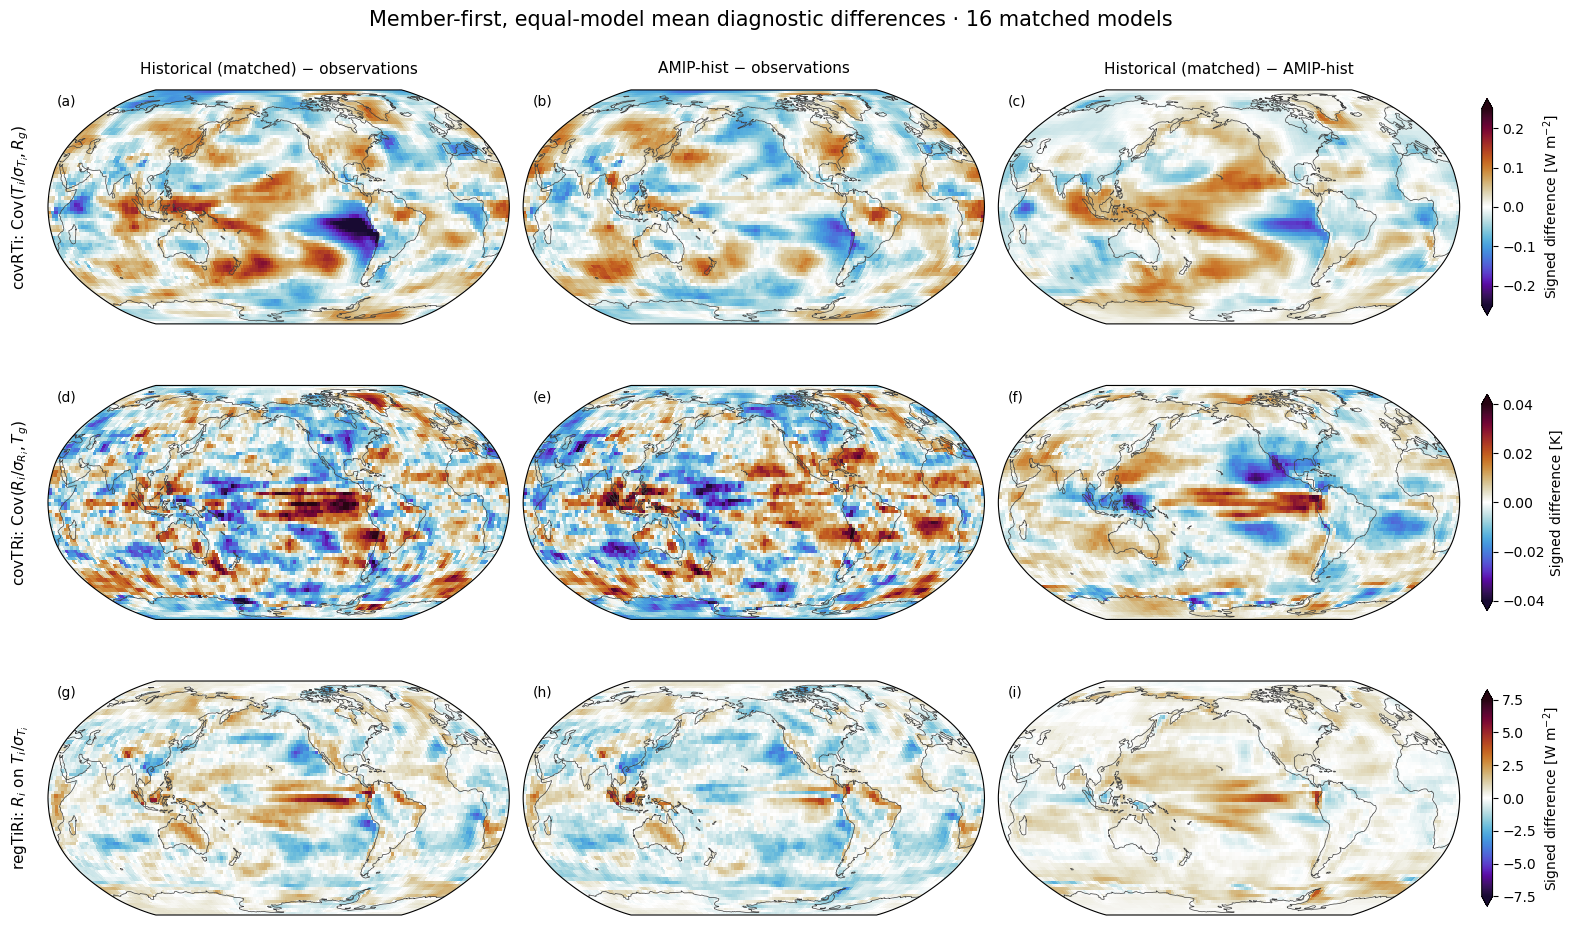

In [19]:
# %% Three diagnostics × three signed differences, with equal model weighting
# Inputs: model_mean_maps, MMM_model_names, covRTi_obs, covTRi_obs, regTiRi_obs,
#         lat, lon. The diagnostic was already calculated separately per member
#         and then averaged within each model to create model_mean_maps.


bias_metrics = ["covRTi", "covTRi", "regTiRi"]
bias_comparisons = ["historical_minus_obs", "amip_minus_obs", "historical_minus_amip"]
bias_observations = {"covRTi": covRTi_obs, "covTRi": covTRi_obs, "regTiRi": regTiRi_obs}
bias_column_titles = ["Historical (matched) − observations", "AMIP-hist − observations", "Historical (matched) − AMIP-hist"]
bias_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
bias_row_labels = {
    "covRTi": r"covRTi: Cov($T_i/\sigma_{T_i}, R_g$)",
    "covTRi": r"covTRi: Cov($R_i/\sigma_{R_i}, T_g$)",
    "regTiRi": r"regTiRi: $R_i$ on $T_i/\sigma_{T_i}$",
}

# Display settings only: one symmetric, linear scale shared across each row.
# Percentiles use all THREE difference maps together; values beyond the limits
# remain in the data and saturate in color. Set 100 to include every finite value.
bias_percentile, bias_cmap, bias_central_longitude = 100, cmr.fusion_r, 210
bias_vlims = {"covRTi": 0.25, "covTRi": 0.04, "regTiRi": 7.5}  # Or positive manual limits.
bias_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/bias/MMM_bias.png" # E.g. Path("./plots/obs/mmm_spatial_bias_maps.svg")

# Match by model NAME, not array position; these saved lists identify map axes.
# All saved matched models are included, irrespective of any earlier scatter
# outlier exclusion. Historical and AMIP members need not pair one-to-one.
bias_map_model_names = list(MMM_model_names["amip_hist"])
bias_hist_names = list(MMM_model_names["historical_matched"])
if (not bias_map_model_names or len(set(bias_map_model_names)) != len(bias_map_model_names)
        or len(set(bias_hist_names)) != len(bias_hist_names)
        or set(bias_hist_names) != set(bias_map_model_names)):
    raise ValueError("AMIP and historical_matched must contain the same nonempty, unique model set.")
bias_hist_order = [bias_hist_names.index(model) for model in bias_map_model_names]
bias_lat, bias_lon = np.asarray(lat), np.asarray(lon)
if bias_lat.ndim != 1 or bias_lon.ndim != 1 or min(len(bias_lat), len(bias_lon)) < 2:
    raise ValueError("This map cell expects 1D latitude and longitude coordinates with at least two points each.")
if not np.isfinite(bias_lat).all() or not np.isfinite(bias_lon).all():
    raise ValueError("Latitude and longitude coordinates must be finite.")
if not 0 < bias_percentile <= 100:
    raise ValueError("bias_percentile must be in (0, 100].")
bias_shape = (len(bias_lat), len(bias_lon))

# First form each MODEL's signed difference map, then average equally over models.
# Subtracting a fixed observation commutes with the existing member mean: this
# equals averaging member-minus-observation maps within each model first.
# The common mask uses paired finite model means and finite observations. Thus
# all columns use the SAME models at each cell; retain their counts for inspection.
model_bias_maps = {comparison: {} for comparison in bias_comparisons}
MMM_bias_maps = {comparison: {} for comparison in bias_comparisons}
bias_map_n_models, bias_color_limits = {}, {}
for metric in bias_metrics:
    historical = np.ma.asarray(model_mean_maps["historical_matched"][metric], dtype=float).filled(np.nan)
    amip = np.ma.asarray(model_mean_maps["amip_hist"][metric], dtype=float).filled(np.nan)
    observation = np.ma.asarray(bias_observations[metric], dtype=float).filled(np.nan)
    expected = (len(bias_map_model_names), *bias_shape)
    if historical.shape != expected or amip.shape != expected or observation.shape != bias_shape:
        raise ValueError(f"{metric}: model stacks must be {expected}; observations must be {bias_shape}.")
    historical = historical[bias_hist_order]
    valid = np.isfinite(historical) & np.isfinite(amip) & np.isfinite(observation)[None, :, :]
    count = valid.sum(axis=0)
    bias_map_n_models[metric] = count
    differences = [historical - observation, amip - observation, historical - amip]
    for comparison, difference in zip(bias_comparisons, differences):
        model_bias_maps[comparison][metric] = np.where(valid, difference, np.nan)
        total = np.where(valid, difference, 0.).sum(axis=0)
        MMM_bias_maps[comparison][metric] = np.divide(total, count, out=np.full(bias_shape, np.nan), where=count > 0)

    # Algebraic check, not a significance test. No extra area weighting belongs
    # in these pointwise model averages; weights already entered the diagnostics.
    np.testing.assert_allclose(
        MMM_bias_maps["historical_minus_obs"][metric] - MMM_bias_maps["amip_minus_obs"][metric],
        MMM_bias_maps["historical_minus_amip"][metric], rtol=1e-10, atol=1e-12, equal_nan=True
    )
    row_maps = np.stack([MMM_bias_maps[comparison][metric] for comparison in bias_comparisons])
    finite = np.abs(row_maps[np.isfinite(row_maps)])
    if not finite.size:
        raise ValueError(f"{metric}: no common finite model/observation support remains.")
    limit = bias_vlims[metric]
    if limit is None:
        limit = float(np.percentile(finite, bias_percentile))
        limit = float(finite.max()) if limit == 0 else limit
        limit = 1.0 if limit == 0 else limit
    if not np.isfinite(limit) or limit <= 0:
        raise ValueError(f"{metric}: color limit must be positive and finite.")
    bias_color_limits[metric] = float(limit)
    print(f"{metric}: {count[count > 0].min()}–{count.max()} paired models per plotted cell; color limits ±{limit:.3g}")

# Plot signed physical-unit differences; red means the FIRST field is higher.
# One colorbar per row avoids mixing covTRi's temperature units with radiation
# units. Blank cells lack paired support, not necessarily statistical significance.
fig_MMM_bias, axes_MMM_bias = plt.subplots(
    3, 3, figsize=(17, 10), subplot_kw={"projection": ccrs.Robinson(central_longitude=bias_central_longitude)}
)
fig_MMM_bias.subplots_adjust(left=0.075, right=0.94, top=0.91, bottom=0.055, wspace=0.03, hspace=0.12)
for row, metric in enumerate(bias_metrics):
    limit = bias_color_limits[metric]
    for column, comparison in enumerate(bias_comparisons):
        ax = axes_MMM_bias[row, column]
        values = MMM_bias_maps[comparison][metric]
        # Close the seam on the usual regularly spaced global longitude grid.
        if np.isclose(abs(bias_lon[-1] - bias_lon[0]), 360):
            plot_values, plot_lon = values, bias_lon
        else:
            plot_values, plot_lon = add_cyclic_point(values, coord=bias_lon, axis=-1)
        mesh = ax.pcolormesh(plot_lon, bias_lat, np.ma.masked_invalid(plot_values), shading="auto",
                             cmap=bias_cmap, vmin=-limit, vmax=limit, transform=ccrs.PlateCarree(), rasterized=True)
        ax.set_global()
        ax.coastlines(resolution="110m", linewidth=0.5, color="0.25")
        ax.text(0.02, 0.98, f"({chr(97 + row * 3 + column)})", transform=ax.transAxes, va="top", fontsize=10)
        if row == 0:
            ax.set_title(bias_column_titles[column], fontsize=11, pad=12)
    axes_MMM_bias[row, 0].text(-0.06, 0.5, bias_row_labels[metric], transform=axes_MMM_bias[row, 0].transAxes,
                              rotation=90, ha="center", va="center", fontsize=11)
    colorbar = fig_MMM_bias.colorbar(mesh, ax=list(axes_MMM_bias[row]), orientation="vertical",
                                     fraction=0.025, pad=0.015, shrink=0.82, extend="both")
    colorbar.set_label("Signed difference [" + bias_units[metric] + "]", fontsize=10)
fig_MMM_bias.suptitle(f"Member-first, equal-model mean diagnostic differences · {len(bias_map_model_names)} matched models",
                      fontsize=15, y=0.975)
if bias_savepath is not None:
    bias_savepath = Path(bias_savepath)
    bias_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_MMM_bias.savefig(bias_savepath, dpi=250, bbox_inches="tight")
plt.show()


Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/grid_v_obs.png


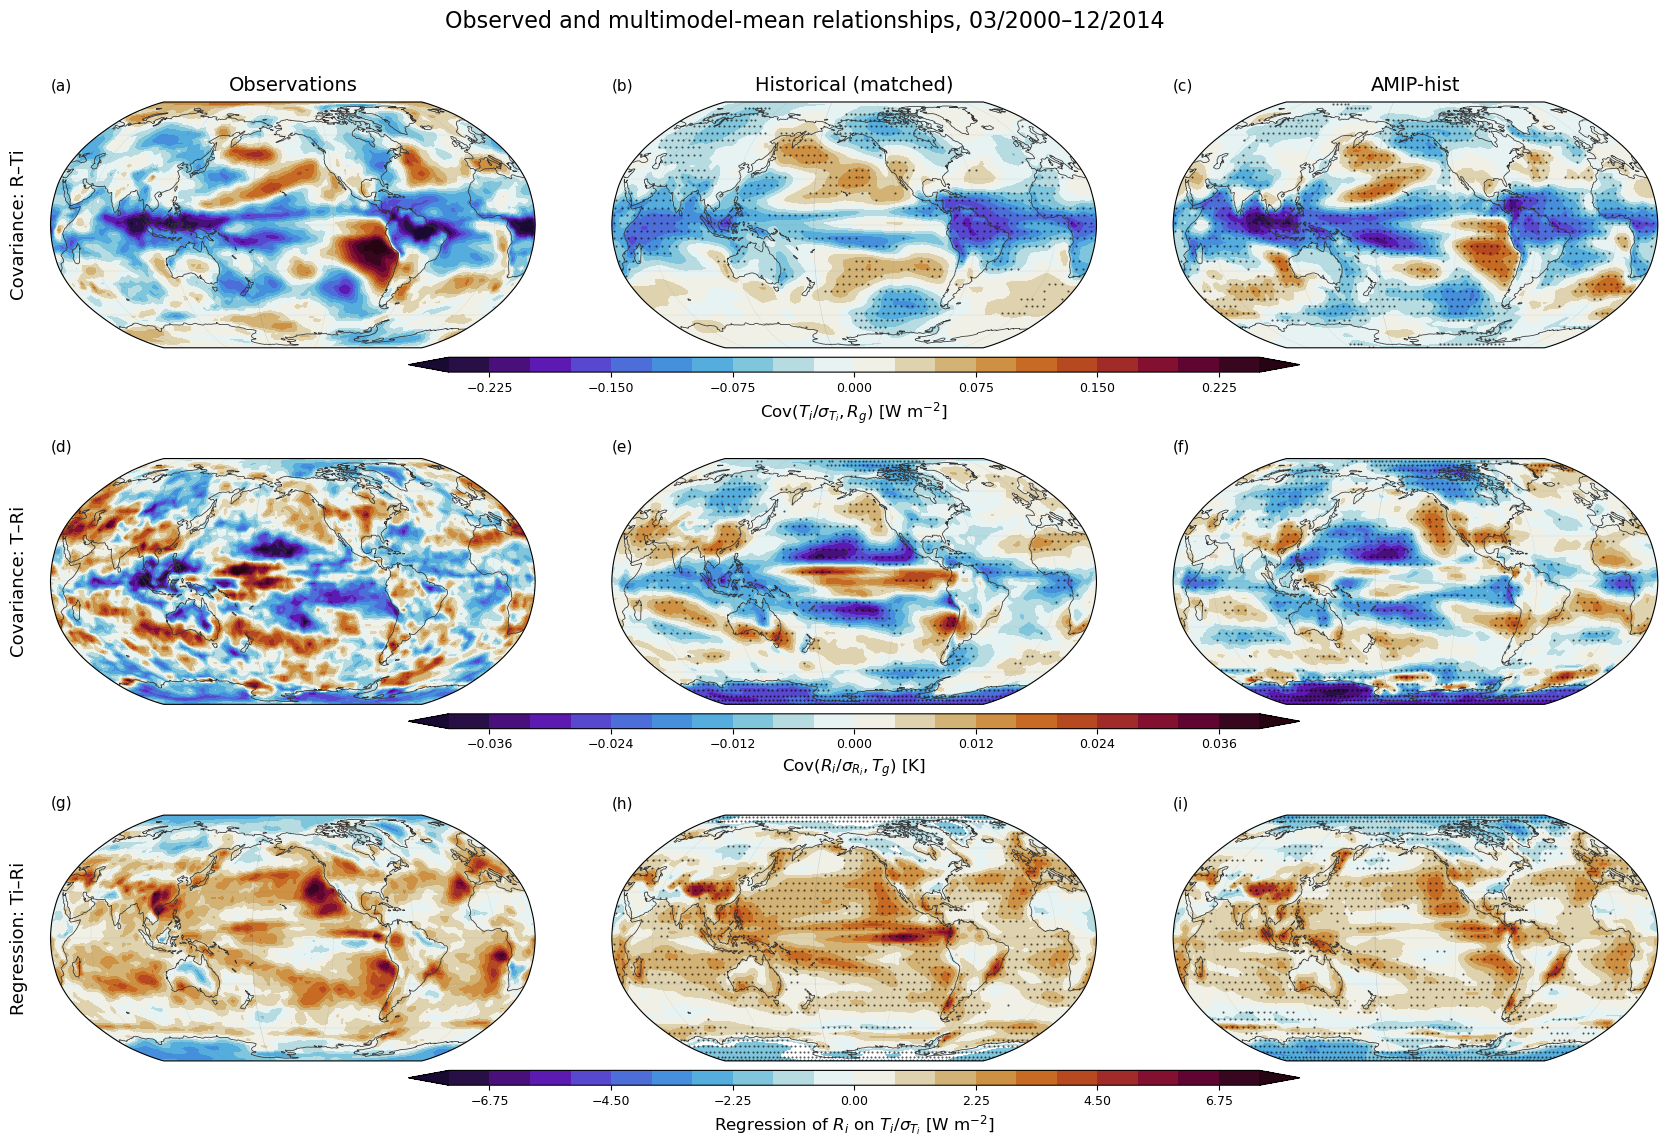

In [18]:
import cmasher as cmr                 # Registers "cmr.fusion_r", as in your example.

relationship_grid_metrics = ["covRTi", "covTRi", "regTiRi"]
relationship_grid_observations = [covRTi_obs, covTRi_obs, regTiRi_obs]
relationship_hist_experiment = "historical_matched"  # Use "historical" for all coupled models instead.

# With matched historical, verify that both MMMs refer to the same model set.
# This cannot independently verify stale saved maps/stats; load matching versions.
if relationship_hist_experiment == "historical_matched":
    hist_names, amip_names = list(MMM_model_names[relationship_hist_experiment]), list(MMM_model_names["amip_hist"])
    if (not hist_names or set(hist_names) != set(amip_names)
            or len(hist_names) != len(set(hist_names)) or len(amip_names) != len(set(amip_names))):
        raise ValueError("historical_matched and amip_hist must describe the same nonempty, unique model set.")

# Shape: (diagnostic row, dataset column, lat, lon). These are diagnostic VALUES,
# not the difference/bias maps from the preceding 3×3 figure.
relationship_grid_maps = np.stack([
    np.stack([observation, MMM_maps[relationship_hist_experiment][metric], MMM_maps["amip_hist"][metric]])
    for metric, observation in zip(relationship_grid_metrics, relationship_grid_observations)
])
relationship_grid_robust_masks = [
    [None, MMM_stats[relationship_hist_experiment][metric]["robust"], MMM_stats["amip_hist"][metric]["robust"]]
    for metric in relationship_grid_metrics
]

fig_relationship_grid, axes_relationship_grid = plot_3x3_relationship_maps(
    maps=relationship_grid_maps, lat=lat, lon=lon,
    row_titles=["Covariance: R–Ti", "Covariance: T–Ri", "Regression: Ti–Ri"],
    column_titles=["Observations", "Historical (matched)" if relationship_hist_experiment == "historical_matched"
                   else "Historical (all models)", "AMIP-hist"],
    colorbar_labels=[r"Cov($T_i/\sigma_{T_i}, R_g$) [W m$^{-2}$]",
                     r"Cov($R_i/\sigma_{R_i}, T_g$) [K]",
                     r"Regression of $R_i$ on $T_i/\sigma_{T_i}$ [W m$^{-2}$]"],
    figure_title="Observed and multimodel-mean relationships, 03/2000–12/2014",
    central_longitude=210, cmaps="cmr.fusion_r", vlims=[0.25, 0.04, 7.5],
    robust_masks=relationship_grid_robust_masks, overlay_style="stipple", overlay_for="significant",
    stipple_stride=2, stipple_size=9.0,
    savepath="/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/grid_v_obs.png",
)
plt.show()


In [20]:
# Inputs: model_mean_maps, MMM_model_names, covRTi_obs, covTRi_obs, regTiRi_obs,
#         lat, lon. The diagnostic was already calculated separately per member
#         and then averaged within each model to create model_mean_maps.
import numpy as np
from pathlib import Path

bias_metrics = ["covRTi", "covTRi", "regTiRi"]
bias_comparisons = ["historical_minus_obs", "amip_minus_obs", "historical_minus_amip"]
bias_observations = {"covRTi": covRTi_obs, "covTRi": covTRi_obs, "regTiRi": regTiRi_obs}
bias_column_titles = ["Historical (matched) − observations", "AMIP-hist − observations", "Historical (matched) − AMIP-hist"]
bias_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
bias_row_labels = {
    "covRTi": "Covariance: R–Ti",
    "covTRi": "Covariance: T–Ri",
    "regTiRi": "Regression: Ti–Ri",
}

# Display settings only: one symmetric, linear scale shared across each row.
# Percentiles use all THREE difference maps together; values beyond the limits
# remain in the data and saturate in color. Set 100 to include every finite value.
bias_percentile, bias_cmap, bias_central_longitude = 98, "cmr.fusion_r", 210
bias_vlims = {"covRTi": None, "covTRi": None, "regTiRi": None}  # Or positive manual limits.
# To also match the relationship grid's numerical ranges, set these to 0.25, 0.04, 7.5.
bias_savepath = None                # E.g. Path("./plots/obs/mmm_spatial_bias_maps.svg")

# Match by model NAME, not array position; these saved lists identify map axes.
# All saved matched models are included, irrespective of any earlier scatter
# outlier exclusion. Historical and AMIP members need not pair one-to-one.
bias_map_model_names = list(MMM_model_names["amip_hist"])
bias_hist_names = list(MMM_model_names["historical_matched"])
if (not bias_map_model_names or len(set(bias_map_model_names)) != len(bias_map_model_names)
        or len(set(bias_hist_names)) != len(bias_hist_names)
        or set(bias_hist_names) != set(bias_map_model_names)):
    raise ValueError("AMIP and historical_matched must contain the same nonempty, unique model set.")
bias_hist_order = [bias_hist_names.index(model) for model in bias_map_model_names]
bias_lat, bias_lon = np.asarray(lat), np.asarray(lon)
if bias_lat.ndim != 1 or bias_lon.ndim != 1 or min(len(bias_lat), len(bias_lon)) < 2:
    raise ValueError("This map cell expects 1D latitude and longitude coordinates with at least two points each.")
if not np.isfinite(bias_lat).all() or not np.isfinite(bias_lon).all():
    raise ValueError("Latitude and longitude coordinates must be finite.")
if not 0 < bias_percentile <= 100:
    raise ValueError("bias_percentile must be in (0, 100].")
bias_shape = (len(bias_lat), len(bias_lon))

# First form each MODEL's signed difference map, then average equally over models.
# Subtracting a fixed observation commutes with the existing member mean: this
# equals averaging member-minus-observation maps within each model first.
# The common mask uses paired finite model means and finite observations. Thus
# all columns use the SAME models at each cell; retain their counts for inspection.
model_bias_maps = {comparison: {} for comparison in bias_comparisons}
MMM_bias_maps = {comparison: {} for comparison in bias_comparisons}
bias_map_n_models, bias_color_limits = {}, {}
for metric in bias_metrics:
    historical = np.ma.asarray(model_mean_maps["historical_matched"][metric], dtype=float).filled(np.nan)
    amip = np.ma.asarray(model_mean_maps["amip_hist"][metric], dtype=float).filled(np.nan)
    observation = np.ma.asarray(bias_observations[metric], dtype=float).filled(np.nan)
    expected = (len(bias_map_model_names), *bias_shape)
    if historical.shape != expected or amip.shape != expected or observation.shape != bias_shape:
        raise ValueError(f"{metric}: model stacks must be {expected}; observations must be {bias_shape}.")
    historical = historical[bias_hist_order]
    valid = np.isfinite(historical) & np.isfinite(amip) & np.isfinite(observation)[None, :, :]
    count = valid.sum(axis=0)
    bias_map_n_models[metric] = count
    differences = [historical - observation, amip - observation, historical - amip]
    for comparison, difference in zip(bias_comparisons, differences):
        model_bias_maps[comparison][metric] = np.where(valid, difference, np.nan)
        total = np.where(valid, difference, 0.).sum(axis=0)
        MMM_bias_maps[comparison][metric] = np.divide(total, count, out=np.full(bias_shape, np.nan), where=count > 0)

    # Algebraic check, not a significance test. No extra area weighting belongs
    # in these pointwise model averages; weights already entered the diagnostics.
    np.testing.assert_allclose(
        MMM_bias_maps["historical_minus_obs"][metric] - MMM_bias_maps["amip_minus_obs"][metric],
        MMM_bias_maps["historical_minus_amip"][metric], rtol=1e-10, atol=1e-12, equal_nan=True
    )
    row_maps = np.stack([MMM_bias_maps[comparison][metric] for comparison in bias_comparisons])
    finite = np.abs(row_maps[np.isfinite(row_maps)])
    if not finite.size:
        raise ValueError(f"{metric}: no common finite model/observation support remains.")
    limit = bias_vlims[metric]
    if limit is None:
        limit = float(np.percentile(finite, bias_percentile))
        limit = float(finite.max()) if limit == 0 else limit
        limit = 1.0 if limit == 0 else limit
    if not np.isfinite(limit) or limit <= 0:
        raise ValueError(f"{metric}: color limit must be positive and finite.")
    bias_color_limits[metric] = float(limit)
    print(f"{metric}: {count[count > 0].min()}–{count.max()} paired models per plotted cell; color limits ±{limit:.3g}")


covRTi: 16–16 paired models per plotted cell; color limits ±0.128
covTRi: 16–16 paired models per plotted cell; color limits ±0.0275
regTiRi: 16–16 paired models per plotted cell; color limits ±2.49


Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/bias_v_obs.png


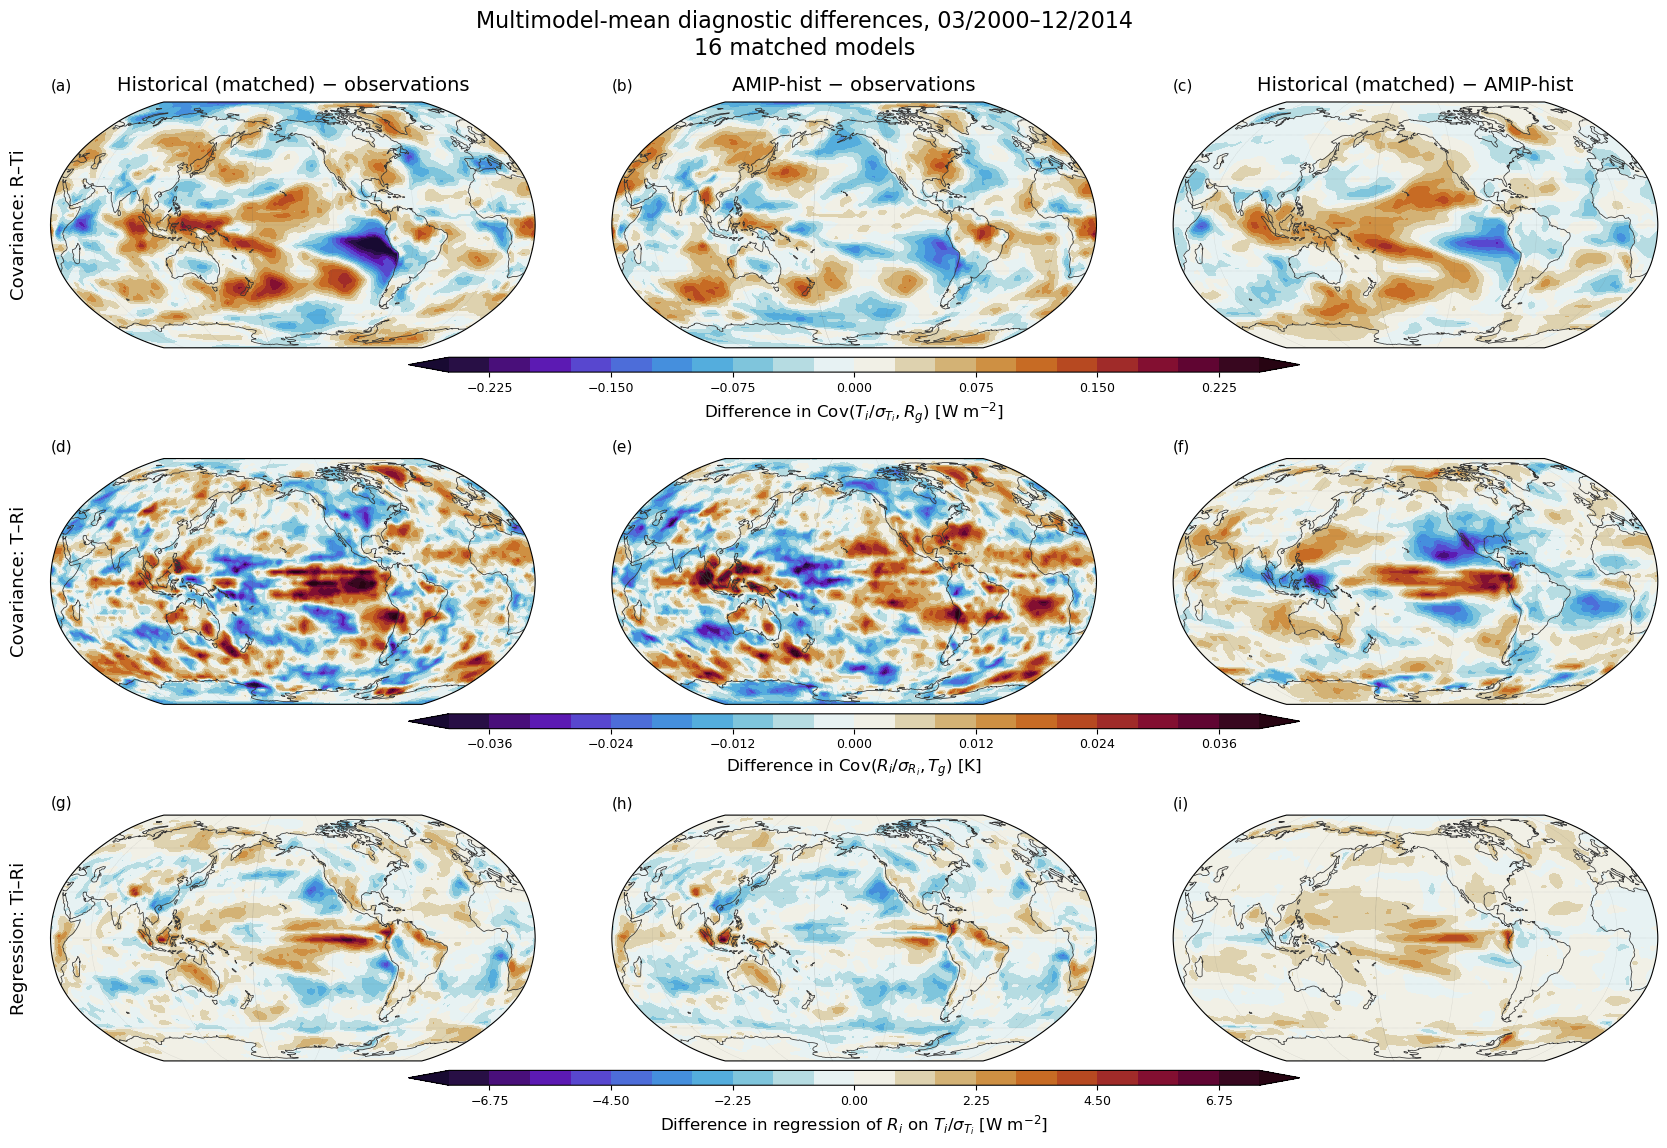

In [23]:
# Run the FIRST function cell of relationship_grid_cells.ipynb once beforehand.
# This cell can then be rerun to change plotting options without recalculating maps.
import matplotlib.pyplot as plt
import cmasher as cmr                 # Registers your "cmr.fusion_r" palette.

if "plot_3x3_relationship_maps" not in globals():
    raise NameError("Run the first function cell in relationship_grid_cells.ipynb before this plotting cell.")

# Shape: (diagnostic row, comparison column, lat, lon), just like the relationship
# grid. Only the maps, column titles, and colorbar wording differ between figures.
bias_grid_maps = np.stack([
    np.stack([MMM_bias_maps[comparison][metric] for comparison in bias_comparisons])
    for metric in bias_metrics
])

# A robustness mask of a diagnostic is NOT a robustness mask of its difference.
# Leave this None unless you supply masks calculated specifically for these
# difference maps: a nested 3×3 list of 2D masks/None, or a matching 4D array.
bias_grid_robust_masks = None

fig_MMM_bias, axes_MMM_bias = plot_3x3_relationship_maps(
    maps=bias_grid_maps, lat=bias_lat, lon=bias_lon,
    row_titles=[bias_row_labels[metric] for metric in bias_metrics], column_titles=bias_column_titles,
    colorbar_labels=[r"Difference in Cov($T_i/\sigma_{T_i}, R_g$) [W m$^{-2}$]",
                     r"Difference in Cov($R_i/\sigma_{R_i}, T_g$) [K]",
                     r"Difference in regression of $R_i$ on $T_i/\sigma_{T_i}$ [W m$^{-2}$]"],
    figure_title=f"Multimodel-mean diagnostic differences, 03/2000–12/2014\n{len(bias_map_model_names)} matched models",
    central_longitude=bias_central_longitude, cmaps=bias_cmap,
    # vlims=[bias_color_limits[metric] for metric in bias_metrics],
    vlims=[0.25, 0.04, 7.5],
    robust_masks=bias_grid_robust_masks, overlay_style="stipple", overlay_for="significant",
    stipple_stride=2, stipple_size=9.0,# savepath=bias_savepath,
    savepath="/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/bias_v_obs.png",
)
plt.show()
